In [101]:
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [102]:
rel_path = "../../data/results/lr_results/final_lr_results.csv"
rel_path_cnn = "../../data/results/cnn_results/cnn_result_last_run.csv"

data = pd.read_csv(rel_path)
data_cnn = pd.read_csv(rel_path_cnn)

In [103]:
# Code for generating plot
# Define the plotting function similar to 'gen_plot_panel' from https://github.com/e-pet/adni-bias/blob/main/analysis.py
def gen_plot_panel(x_var, y_var, data, min_jitter, max_jitter):
    # Perform OLS regression and get the results
    mdl = ols(formula=f'{y_var} ~ {x_var}', data=data)
    results = mdl.fit()
    slope = results.params[1]
    slope_std = results.bse[1]
    p_value = results.pvalues[1]

    # Bonferroni correction: not required here as we only do one test
    corr_factor = 4
    alpha = 0.05
    correction = alpha/corr_factor
    print(f"bonferroni correction {correction}")

        # Perform Wilcoxon test
    _, pval_auc = wilcoxon(data["variation"], data["auroc"], alternative='two-sided')
    _, pval_acc = wilcoxon(data["variation"], data["accuracy"], alternative='two-sided')
    print(f'---- P-VALUE FOR AUC DIFFERENCES: {pval_auc * p_value}')
    print(f'---- P-VALUE FOR ACC DIFFERENCES: {pval_acc * p_value}')
    
    # Plot regression line and annotate with stats
    ax = plt.gca()
    slope_str = f"Slope (m): {slope:.3f} ± {slope_std:.3f}\n"
    p_str = f"p-value (corr): {p_value:.3f}\n"
    mu_str = f"Mean (μ): {data[y_var].mean():.3f} ± {data[y_var].std():.3f}"
    text_str = slope_str + p_str + mu_str
    t = ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=9, verticalalignment='top')
    t.set_bbox(dict(facecolor='white', alpha=0.5, edgecolor='black'))
    
    # Add the regression line
    sns.regplot(x=x_var, y=y_var, data=data, ax=ax, scatter=False, fit_reg=True, color="black", line_kws={'linewidth': 1})
    # Jitter the data points for scatter plot
    data[x_var] = data[x_var] + np.random.uniform(min_jitter, max_jitter, data[x_var].shape)
    # Plot the jittered scatter points
    sns.scatterplot(x=x_var, y=y_var, data=data, hue='variation_hue', s=30, ax=ax, palette="viridis", linewidth=0, alpha=0.7, legend=None)


/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_std = results.bse[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 1.1243119935109055e-10
---- P-VALUE FOR ACC DIFFERENCES: 2.298766663924087e-07
Max AUROC male 0.8550295857988166
Min AUROC male 0.5606508875739644
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 3.3954294531297054e-10
---- P-VALUE FOR ACC DIFFERENCES: 6.942290113073361e-07
Max AUROC female 0.8328402366863905
Min AUROC female 0.57396449704142


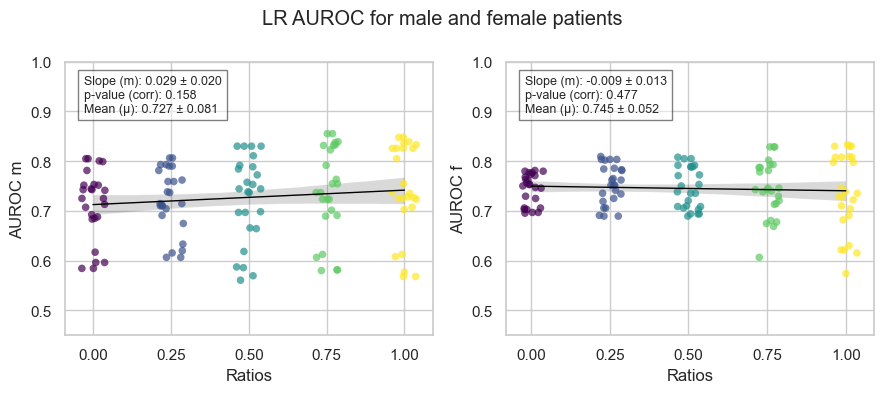

In [104]:
# Adjusted version of the plotting code to include Bonferroni correction and statistical details for both plots

# Set up the subplot grid
plt.figure(figsize=(9, 4))
ax0 = plt.subplot(1, 2, 1)
ax1 = plt.subplot(1, 2, 2)

# Make the first plot
plt.sca(ax0)
df_for_plot = data.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_male', data=df_for_plot, min_jitter=-0.04, max_jitter=0.04)

plt.xticks(ticks=np.linspace(0, data['variation'].max(), num=5))  # Adjust spacing between ticks'

ax0.set_xlabel('Ratios')
ax0.set_ylabel('AUROC m')
ax0.set_ylim(0.45, 1)  # Set y-axis limits
# plt.ylim(bottom=0.5, top=1.0)  # Custom y-axis limits
# plt.savefig('/Users/niko/Documents/uni/6. semester/bsc/Project/BSc-Project/plots/accuracy_vs_ratio_lr.png')
print(f'Max AUROC male {df_for_plot["auroc_male"].max()}')
print(f'Min AUROC male {df_for_plot["auroc_male"].min()}')


# Make the second plot
plt.sca(ax1)
df_for_plot = data.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_female', data=df_for_plot, min_jitter=-0.04, max_jitter=0.04)
plt.xticks(ticks=np.linspace(0, data['variation'].max(), num=5))  # Adjust spacing between ticks

# plt.ylim(bottom=0.5, top=1.0)  # Custom y-axis limits
ax1.set_xlabel('Ratios')
ax1.set_ylabel('AUROC f')
ax1.set_ylim(0.45, 1)  # Set y-axis limits
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.suptitle('LR AUROC for male and female patients')
# plt.savefig('../../analysis/plots/lr_plots/lr_male_auroc_acc.png', dpi=300)
print(f'Max AUROC female {df_for_plot["auroc_female"].max()}')
print(f'Min AUROC female {df_for_plot["auroc_female"].min()}')


plt.tight_layout()
# TODO: Change title and save plot pretty
plt.show()

/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_std = results.bse[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 0.00011787038834440982
---- P-VALUE FOR ACC DIFFERENCES: 0.0016774737343398481
Max AUROC male 0.8713017751479291
Min AUROC male 0.6405325443786982
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 5.9594351303724994e-05
---- P-VALUE FOR ACC DIFFERENCES: 0.0008481176691716695
Max AUROC female 0.8653846153846154
Min AUROC female 0.5340236686390533


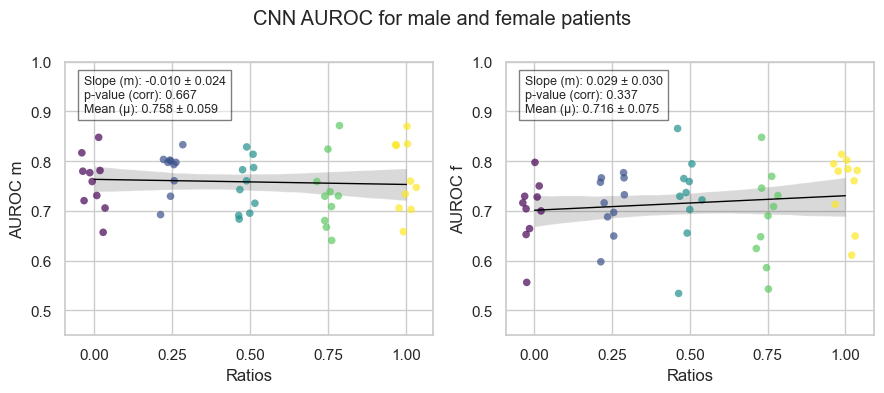

In [105]:
# Adjusted version of the plotting code to include Bonferroni correction and statistical details for both plots

# Set up the subplot grid
plt.figure(figsize=(9, 4))
ax0 = plt.subplot(1, 2, 1)
ax1 = plt.subplot(1, 2, 2)

# Make the first plot
plt.sca(ax0)
df_for_plot = data_cnn.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_male', data=df_for_plot, min_jitter=-0.04, max_jitter=0.04)

plt.xticks(ticks=np.linspace(0, data_cnn['variation'].max(), num=5))  # Adjust spacing between ticks'

ax0.set_xlabel('Ratios')
ax0.set_ylabel('AUROC m')
ax0.set_ylim(0.45, 1)  # Set y-axis limits
# plt.ylim(bottom=0.5, top=1.0)  # Custom y-axis limits
# plt.savefig('/Users/niko/Documents/uni/6. semester/bsc/Project/BSc-Project/plots/accuracy_vs_ratio_lr.png')
print(f'Max AUROC male {df_for_plot["auroc_male"].max()}')
print(f'Min AUROC male {df_for_plot["auroc_male"].min()}')


# Make the second plot
plt.sca(ax1)
df_for_plot = data_cnn.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_female', data=df_for_plot, min_jitter=-0.04, max_jitter=0.04)
plt.xticks(ticks=np.linspace(0, data_cnn['variation'].max(), num=5))  # Adjust spacing between ticks

# plt.ylim(bottom=0.5, top=1.0)  # Custom y-axis limits
ax1.set_xlabel('Ratios')
ax1.set_ylabel('AUROC f')
ax1.set_ylim(0.45, 1)  # Set y-axis limits
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.suptitle('CNN AUROC for male and female patients')
# plt.savefig('../../analysis/plots/lr_plots/lr_male_auroc_acc.png', dpi=300)
print(f'Max AUROC female {df_for_plot["auroc_female"].max()}')
print(f'Min AUROC female {df_for_plot["auroc_female"].min()}')


plt.tight_layout()
# TODO: Change title and save plot pretty
plt.show()

bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 1.1243119935109055e-10
---- P-VALUE FOR ACC DIFFERENCES: 2.298766663924087e-07


/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_std = results.bse[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

Max AUROC male 0.8550295857988166
Min AUROC male 0.5606508875739644
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 3.3954294531297054e-10
---- P-VALUE FOR ACC DIFFERENCES: 6.942290113073361e-07
Max AUROC female 0.8328402366863905
Min AUROC female 0.57396449704142
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 0.00011787038834440982
---- P-VALUE FOR ACC DIFFERENCES: 0.0016774737343398481
Max AUROC male 0.8713017751479291
Min AUROC male 0.6405325443786982
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 5.9594351303724994e-05
---- P-VALUE FOR ACC DIFFERENCES: 0.0008481176691716695
Max AUROC female 0.8653846153846154
Min AUROC female 0.5340236686390533


/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_std = results.bse[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

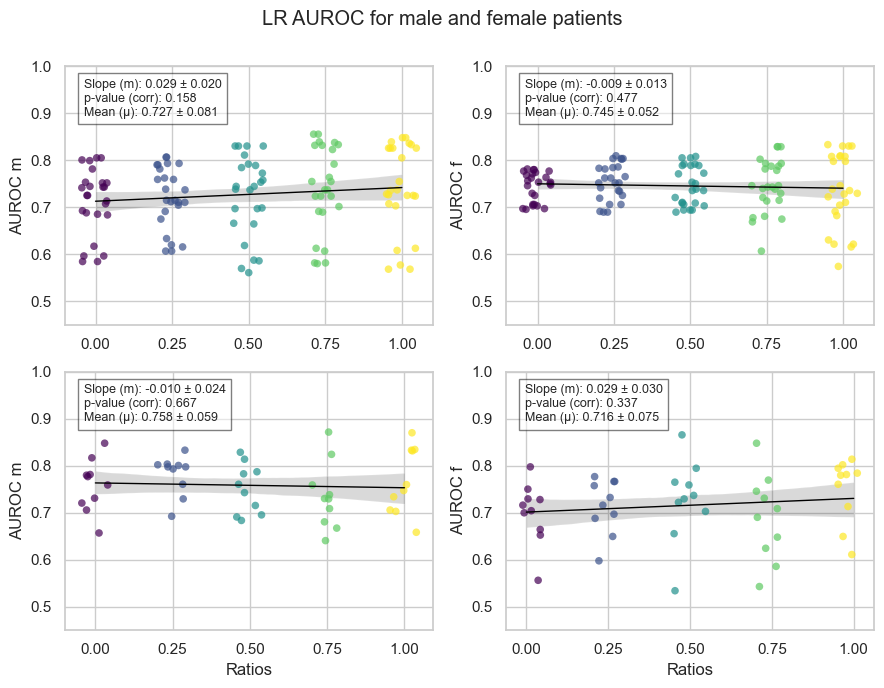

In [106]:
# Adjusted version of the plotting code to include Bonferroni correction and statistical details for both plots

# Set up the subplot grid
plt.figure(figsize=(9, 7))
ax0 = plt.subplot(2, 2, 1)
ax1 = plt.subplot(2, 2, 2)
ax2 = plt.subplot(2, 2, 3)
ax3 = plt.subplot(2, 2, 4)

# Make the first plot
plt.sca(ax0)
df_for_plot = data.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_male', data=df_for_plot, min_jitter=-0.05, max_jitter=0.05)

plt.xticks(ticks=np.linspace(0, data['variation'].max(), num=5))  # Adjust spacing between ticks'

ax0.set_xlabel('')
ax0.set_ylabel('AUROC m')
ax0.set_ylim(0.45, 1)  # Set y-axis limits
print(f'Max AUROC male {df_for_plot["auroc_male"].max()}')
print(f'Min AUROC male {df_for_plot["auroc_male"].min()}')



# Make the second plot
plt.sca(ax1)
df_for_plot = data.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_female', data=df_for_plot, min_jitter=-0.05, max_jitter=0.05)
plt.xticks(ticks=np.linspace(0, data['variation'].max(), num=5))  # Adjust spacing between ticks

# plt.ylim(bottom=0.5, top=1.0)  # Custom y-axis limits
ax1.set_xlabel('')
ax1.set_ylabel('AUROC f')
ax1.set_ylim(0.45, 1)  # Set y-axis limits
print(f'Max AUROC female {df_for_plot["auroc_female"].max()}')
print(f'Min AUROC female {df_for_plot["auroc_female"].min()}')


# Make the third plot
plt.sca(ax2)
df_for_plot = data_cnn.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_male', data=df_for_plot, min_jitter=-0.05, max_jitter=0.05)
plt.xticks(ticks=np.linspace(0, data_cnn['variation'].max(), num=5))  # Adjust spacing between ticks'

ax2.set_xlabel('Ratios')
ax2.set_ylabel('AUROC m')
ax2.set_ylim(0.45, 1)  # Set y-axis limits
print(f'Max AUROC male {df_for_plot["auroc_male"].max()}')
print(f'Min AUROC male {df_for_plot["auroc_male"].min()}')


# Make the fourth plot
plt.sca(ax3)
df_for_plot = data_cnn.copy()
df_for_plot['variation_hue'] = df_for_plot['variation']
gen_plot_panel(x_var='variation', y_var='auroc_female', data=df_for_plot, min_jitter=-0.05, max_jitter=0.05)
plt.xticks(ticks=np.linspace(0, data_cnn['variation'].max(), num=5))  # Adjust spacing between ticks

ax3.set_xlabel('Ratios')
ax3.set_ylabel('AUROC f')
ax3.set_ylim(0.45, 1)  # Set y-axis limits
print(f'Max AUROC female {df_for_plot["auroc_female"].max()}')
print(f'Min AUROC female {df_for_plot["auroc_female"].min()}')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.suptitle('LR AUROC for male and female patients')


# Hide x-axis labels for the first 
# plt.savefig('lr_plots/acc_auroc_f_m_lr.png')


plt.show()

/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_std = results.bse[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 1.1243119935109055e-10
---- P-VALUE FOR ACC DIFFERENCES: 2.298766663924087e-07
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 3.3954294531297054e-10
---- P-VALUE FOR ACC DIFFERENCES: 6.942290113073361e-07


/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_std = results.bse[1]
/var/folders/yq/d0xp5r_x1nv_sbq6087fhk5c0000gn/T/ipykernel_60428/2724498143.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 0.00011787038834440982
---- P-VALUE FOR ACC DIFFERENCES: 0.0016774737343398481
bonferroni correction 0.0125
---- P-VALUE FOR AUC DIFFERENCES: 5.9594351303724994e-05
---- P-VALUE FOR ACC DIFFERENCES: 0.0008481176691716695


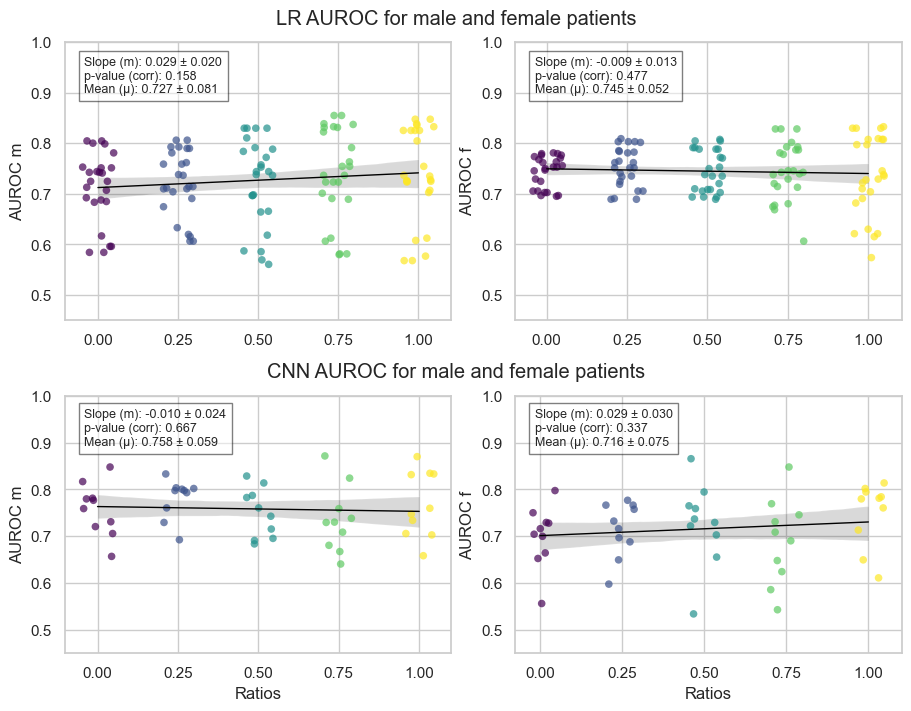

In [107]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(9, 7), constrained_layout=True)
# fig.suptitle('Figure title')

# clear subplots
for ax in axs:
    ax.remove()

# add subfigure per subplot
gridspec = axs[0].get_subplotspec().get_gridspec()
subfigs = [fig.add_subfigure(gs) for gs in gridspec]

for row, subfig in enumerate(subfigs):
    df_for_plot = data.copy()
    list1 = ["LR AUROC for male and female patients", "CNN AUROC for male and female patients"]
    subfig.suptitle(list1[0+row])

    df_source = data if row == 0 else data_cnn


    # create 1x3 subplots per subfig
    axs = subfig.subplots(nrows=1, ncols=2)
    for col, ax in enumerate(axs):
        y_var = 'auroc_male' if col == 0 else 'auroc_female'
        ylabel = 'AUROC m' if col == 0 else 'AUROC f'

        df_for_plot = df_source.copy()
        df_for_plot['variation_hue'] = df_for_plot['variation']
        plt.sca(ax)
        gen_plot_panel(x_var='variation', y_var=y_var, data=df_for_plot, min_jitter=-0.05, max_jitter=0.05)
        plt.xticks(ticks=np.linspace(0, df_source['variation'].max(), num=5))

        ax.set_xlabel('Ratios' if row == 1 else '')
        ax.set_ylabel(ylabel)
        ax.set_ylim(0.45, 1)

plt.savefig('common_plots/fin_auroc_f_m_lrcnn.png', dpi=1000)
plt.show()
